In [3]:
import os
import json
from pathlib import Path
import time
import uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dimod
from neal import SimulatedAnnealingSampler
from dwave.system import DWaveSampler, EmbeddingComposite, LeapHybridSampler

In [21]:
def _to_float(x):
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if isinstance(x, str):
        return float(x.strip())
    return float(x)

def _parse_int(s):
    return int(str(s).strip())

def _parse_cuadratica_key(k):
    """
    Acepta:
      - "i,j"
      - " i , j "
      - ("i","j") o [i,j]
    """
    if isinstance(k, (tuple, list)) and len(k) == 2:
        return _parse_int(k[0]), _parse_int(k[1])

    k = str(k)
    parts = [p.strip() for p in k.split(",")]
    if len(parts) != 2:
        raise ValueError(f"Clave cuadrática no válida: {k!r}")
    return _parse_int(parts[0]), _parse_int(parts[1])

def load_qubo_json_flexible(json_path):
    """
    Carga un QUBO desde JSON en formatos variantes y devuelve:
      lineal: dict[int,float]
      cuadratica: dict[(int,int),float]
      desplazamiento: float
      meta: dict con N, ciudades, n_slots, indices_depositos/origenes_indx, varmap...
    """
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    # -------- meta --------
    meta = {}
    for k in ["N", "ciudades", "n_slots", "varmap"]:
        if k in obj:
            meta[k] = obj[k]

    # soportar ambos nombres
    if "indices_depositos" in obj:
        meta["indices_depositos"] = obj["indices_depositos"]
    elif "origenes_indx" in obj:
        meta["indices_depositos"] = obj["origenes_indx"]

    # -------- offset / desplazamiento --------
    if "desplazamiento" in obj:
        desplazamiento = _to_float(obj["desplazamiento"])
    else:
        desplazamiento = _to_float(obj.get("offset", 0.0))

    # -------- lineal / linear --------
    lineal_raw = obj.get("lineal")
    if lineal_raw is None:
        lineal_raw = obj.get("linear", {})

    lineal = {}
    if isinstance(lineal_raw, dict):
        for k, v in lineal_raw.items():
            lineal[_parse_int(k)] = _to_float(v)
    elif isinstance(lineal_raw, list):
        for it in lineal_raw:
            lineal[_parse_int(it["i"])] = _to_float(it["v"])
    else:
        raise ValueError("Formato de 'lineal'/'linear' no soportado")

    # -------- cuadratica / quadratic --------
    cuadratica_raw = obj.get("cuadratica")
    if cuadratica_raw is None:
        cuadratica_raw = obj.get("quadratic", {})

    quad_acc = {}
    if isinstance(cuadratica_raw, dict):
        items = cuadratica_raw.items()
    elif isinstance(cuadratica_raw, list):
        items = [((it["i"], it["j"]), it["v"]) for it in cuadratica_raw]
    else:
        raise ValueError("Formato de 'cuadratica'/'quadratic' no soportado")

    for k, v in items:
        i, j = _parse_cuadratica_key(k)
        c = _to_float(v)

        if i == j:
            lineal[i] = lineal.get(i, 0.0) + c
            continue

        a, b = (i, j) if i < j else (j, i)
        quad_acc[(a, b)] = quad_acc.get((a, b), 0.0) + c

    cuadratica = {k: v for k, v in quad_acc.items() if abs(v) > 1e-12}
    lineal = {k: v for k, v in lineal.items() if abs(v) > 1e-12}

    # -------- normalización opcional de meta --------
    if "N" in meta:
        meta["N"] = int(meta["N"])
    if "n_slots" in meta:
        meta["n_slots"] = int(meta["n_slots"])
    if "varmap" in meta and isinstance(meta["varmap"], dict):
        meta["varmap"] = {int(k): tuple(v) for k, v in meta["varmap"].items()}
    if "indices_depositos" in meta:
        meta["indices_depositos"] = [int(x) for x in meta["indices_depositos"]]

    return lineal, cuadratica, desplazamiento, meta

def load_npz_meta(npz_path):
    """
    Carga metadatos (p.ej. costes, ciudades, n_slots) desde NPZ.
    """
    z = np.load(npz_path, allow_pickle=True)
    meta = {}
    for k in z.files:
        meta[k] = z[k].item() if z[k].shape == () else z[k]
    return meta

def merge_meta(meta_json, meta_npz):
    out = dict(meta_json) if meta_json else {}
    if meta_npz:
        out.update(meta_npz)
    return out

def asegurar_bits(x, N):
    """
    Normaliza una solución binaria (bitstring) a un vector NumPy 0/1 de longitud N.

    Esta función se usa para unificar el formato de las soluciones provenientes de distintas fuentes:
    - Simulador adiabático / Ising (a veces devuelve arrays/listas de 0/1).
    - dwave-3 / QCI (a veces devuelve un entero que codifica el bitstring).

    Params
    ----------
    x : int | list[int] | tuple[int] | np.ndarray
        Representación de la solución.
        - Si es lista/tupla/ndarray: se interpreta como vector binario explícito.
        - Si es int: se interpreta como un bitstring empaquetado en un entero (bits de x).

    N : int
        Número total de variables binarias (qubits) esperadas.
        Debe coincidir exactamente con el tamaño del vector resultante.

    Returns
    -------
    np.ndarray
        Vector 1D de longitud N con valores {0,1}, dtype=int.
        La convención para el caso entero es:
        - Se devuelve el bit más significativo primero (MSB → LSB), es decir,
          el primer elemento corresponde al bit de orden N-1 y el último al bit 0.
    """
    
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.array(x, dtype=int).ravel()
        
        if arr.size != N:
            raise ValueError(f"Tamaño de bits {arr.size} != N ({N}).")
        return arr
        
    return np.array([(x >> k) & 1 for k in range(N-1, -1, -1)], dtype=int)

def energia_qubo(bits, lineal, cuadratica, desplazamiento=0.0):
    """
    Calcula la energía de un QUBO para un bitstring dado.

    Evalúa la expresión típica de un QUBO:
        E(x) = desplazamiento + sum_i (L_i * x_i) + sum_{i,j} (Q_{i,j} * x_i * x_j)
    donde:
        - x_i ∈ {0,1} son las variables binarias (qubits).
        - L_i son coeficientes lineales.
        - Q_{i,j} son coeficientes cuadráticos (acoplamientos).
        - desplazamiento (desplazamiento) es un término constante.

    Params
    ----------
    bits : array-like
        Vector binario (0/1) con la asignación de todas las variables del QUBO.
        Debe tener longitud al menos max(i,j)+1 para los índices presentes en 'lineal' y 'cuadratica'.

    lineal : dict[int, float]
        Diccionario de términos lineales. Clave = índice i, valor = coeficiente L_i.
        Ejemplo: {0: -1.2, 3: 0.5}

    cuadratica : dict[tuple[int,int], float]
        Diccionario de términos cuadráticos. Clave = (i,j), valor = coeficiente Q_{i,j}.
        Ejemplo: {(0,3): 2.0, (1,2): -0.7}
        
    desplazamiento : float, opcional
        Término constante (desplazamiento) que se suma a la energía. Por defecto 0.0.

    Returns
    -------
    float
        Energía total E(bits) evaluada sobre el bitstring.
    """
    
    e = float(desplazamiento)
    for i, a in lineal.items():
        e += a * bits[i]
        
    for (i, j), c in cuadratica.items():
        e += c * bits[i] * bits[j]
        
    return float(e)

def verificar_restricciones(bits, mapa_vars, n_posiciones, indices_depositos=0, n_ciudades=None, K_esperado=None):
    """
    Verifica restricciones de factibilidad sobre una solución binaria (bitstring) del MVRP codificado como QUBO.

    Esta función reconstruye la matriz one-hot X[i,t] (ciudad i en el slot/tiempo t) a partir del bitstring
    y del mapeo de variables `mapa_vars`. A partir de X calcula métricas de violación típicas del encoding.

    Params
    ----------
    bits : array-like
        Vector 0/1 que representa una solución candidata del QUBO. Se aplana a 1D.
        Debe tener longitud al menos igual al mayor índice de `mapa_vars` + 1.

    mapa_vars : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice del qubit/variable. Valor: (i, t).
        Ejemplo: {0: (0,0), 1: (1,0), 2: (0,1), ...}.

    n_posiciones : int
        Número total de slots/tiempos (T). Es el ancho de la matriz X[i,t].

    indices_depositos : int | list[int] | tuple[int] | set[int], opcional
        Índices de las ciudades que se consideran depósitos. Se normaliza internamente a un set de enteros.
        - Si se pasa un int, se interpreta como un único depósito.
        - Si se pasa colección, se interpreta como multi-depósito.

    n_ciudades : int, opcional
        Número total de ciudades. Si es None, se infiere a partir de `mapa_vars` (máximo i + 1).

    K_esperado : int | None, opcional
        Valor esperado de apariciones de depósitos (por ejemplo, K vehículos o nº de separadores en la secuencia).
        - Si es None: se fija K_esperado = K_encontrado y se pone viol_deposito = 0 (criterio informativo).
        - Si es un int: se valida contra K_encontrado.

    Returns
    -------
    dict
        Diccionario con:
        - "viol_pos"      : int, nº de slots que no cumplen one-hot.
        - "viol_una"      : int, nº de ciudades no-depósito que no aparecen exactamente una vez.
        - "viol_deposito" : int, 0/1 indicando si se cumple K_esperado (si se proporciona) o 0 si no se valida.
        - "K_encontrado"  : int, apariciones totales de depósitos en X.
        - "K_esperado"    : int, el K esperado usado en la comparación (o K_encontrado si no se proporcionó).
    """
    
    if n_ciudades is None:
        n_ciudades = max(i for (i, _t) in mapa_vars.values()) + 1

    bits = np.array(bits, dtype=int).ravel()

    # normalizar depósitos a set[int]
    if isinstance(indices_depositos, (set, list, tuple)):
        depot_set = set(int(x) for x in indices_depositos)
    else:
        depot_set = {int(indices_depositos)}

    X = np.zeros((n_ciudades, n_posiciones), dtype=int)
    for idx, (i, t) in mapa_vars.items():
        if idx < bits.size:
            X[i, t] = int(bits[idx])

    # 1 por posición
    por_posicion = np.sum(X, axis=0)
    viol_pos = int(np.sum(por_posicion != 1))

    # cada NO-depósito exactamente 1 vez
    por_ciudad = np.sum(X, axis=1)
    mascara_no_deposito = np.ones(n_ciudades, dtype=bool)
    
    for d in depot_set:
        if 0 <= d < n_ciudades:
            mascara_no_deposito[d] = False
    viol_una = int(np.sum(por_ciudad[mascara_no_deposito] != 1))

    # cuántas veces aparecen depósitos (multi-depósito)
    dep_list = [d for d in depot_set if 0 <= d < n_ciudades]
    K_encontrado = int(np.sum(X[dep_list, :])) if dep_list else 0

    # Segmento que evita resultdos de tipo 0/0 en k_encontrado/esperado
    if K_esperado is None:
        K_esperado = K_encontrado
        viol_deposito = 0
        
    else:
        K_esperado = int(K_esperado)
        if K_encontrado == K_esperado:
            viol_deposito = 0
        else:
            viol_deposito = 1

    return {
        "viol_pos": viol_pos,
        "viol_una": viol_una,
        "viol_deposito": viol_deposito,
        "K_encontrado": K_encontrado,
        "K_esperado": K_esperado
    }

def decodificar_ruta_multi(bits, mapa_vars, ciudades, n_posiciones, indices_depositos, circular=False):
    """
    Decodifica un bitstring del QUBO MVRP a:
      (1) una secuencia de ciudades por slot y
      (2) una lista de rutas segmentadas usando los depósitos como separadores.

    La codificación subyacente asume variables binarias x_{i,t} que indican si en el slot/tiempo t
    se elige la ciudad i. A partir de `bits` y `mapa_vars` se reconstruye una matriz X[i,t] y se
    obtiene la ciudad activa en cada slot tomando argmax por columna.

    Segmentación en rutas
    ---------------------
    Se considera que cada vez que aparece un depósito en la secuencia, se "cierra" la ruta actual
    y comienza una nueva. En concreto:
      - Los depósitos actúan como separadores.
      - Los clientes (no depósitos) se agregan a la ruta actual.
      - Si hay depósitos consecutivos, la ruta intermedia queda vacía y NO se añade (por diseño),
        ya que solo se añade una ruta si contiene al menos un cliente.

    Modos de funcionamiento
    -----------------------
    circular = False (abierto):
        Interpreta la secuencia como lineal de longitud n_posiciones.
        Ejemplo: D -> A -> B -> D -> C  (rutas: [D:A-B], [D:C])

    circular = True (circular/anillo):
        Interpreta la secuencia como un ciclo.
        - Primero rota la secuencia para empezar en el primer depósito encontrado (si existe).
        - Luego añade el primer elemento al final para "cerrar" el ciclo.
        Nota: la secuencia devuelta tiene longitud n_posiciones + 1 en este modo.

    Params
    ----------
    bits : array-like
        Vector binario 0/1 (o equivalente) con la solución del QUBO. Se aplana a 1D.
        Si hay violaciones one-hot, argmax elige la ciudad con mayor activación en cada slot.

    mapa_vars : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice del qubit/variable. Valor: (i, t).

    ciudades : list[str]
        Lista con los nombres de todas las ciudades (depósitos primero o mezclados según tu construcción).
        Se usa para convertir índices a nombres legibles.

    n_posiciones : int
        Número total de slots/tiempos (T) de la codificación.

    indices_depositos : int | list[int] | tuple[int] | set[int]
        Índices de las ciudades que se consideran depósitos. Se normaliza internamente a set[int].

    circular : bool, opcional
        - False: secuencia abierta (lineal).
        - True : secuencia circular (rota y cierra el anillo).
        Por defecto False.

    Return
    -------
    tuple[list[str], list[tuple[str, list[str]]]]
        - secuencia_nombres: lista con la ciudad elegida en cada slot (en modo circular, incluye el cierre).
        - rutas: lista de tuplas (deposito_inicio, [clientes...]) para cada segmento no vacío.
    """
    
    n_ciudades = len(ciudades)
    bits = np.array(bits, dtype=int).ravel()

    # normalizar depósitos a set[int]
    if isinstance(indices_depositos, (set, list, tuple)):
        depot_set = set(int(x) for x in indices_depositos)
    else:
        depot_set = {int(indices_depositos)}

    X = np.zeros((n_ciudades, n_posiciones), dtype=int)
    for idx, (i, t) in mapa_vars.items():
        if idx < bits.size:
            X[i, t] = int(bits[idx])

    secuencia_indices = []
    for t in range(n_posiciones):
        secuencia_indices.append(int(np.argmax(X[:, t])))

    # --- modo circular: rotar a primer depósito y cerrar el anillo ---
    if circular:
        try:
            start_idx = next(k for k, x in enumerate(secuencia_indices) if x in depot_set)
        except StopIteration:
            start_idx = 0
        ring = secuencia_indices[start_idx:] + secuencia_indices[:start_idx]
        ring = ring + [ring[0]]  # cerrar
        secuencia_indices = ring  # longitud = n_posiciones + 1

    secuencia_nombres = [ciudades[i] for i in secuencia_indices]

    rutas = []
    actual = []

    # depósito inicial
    deposito_inicio_actual = None
    try:
        deposito_inicio_actual = next(i for i in secuencia_indices if i in depot_set)
    except StopIteration:
        deposito_inicio_actual = secuencia_indices[0]

    deposito_inicio_actual_nombre = ciudades[deposito_inicio_actual]

    # iteración
    for idx_ciudad in secuencia_indices[1:]:
        nombre_ciudad = ciudades[idx_ciudad]
        if idx_ciudad in depot_set:
            if actual:
                rutas.append((deposito_inicio_actual_nombre, actual))
            actual = []
            deposito_inicio_actual_nombre = nombre_ciudad
        else:
            actual.append(nombre_ciudad)

    if actual:
        rutas.append((deposito_inicio_actual_nombre, actual))

    return secuencia_nombres, rutas
    
def evaluar_bits(bits, lineal, cuadratica, desplazamiento, mapa_vars, ciudades, n_posiciones, costes,
                indices_depositos, circular=False, K_esperado=None):
    """
    Evalúa un bitstring candidato del QUBO MVRP y devuelve métricas comparables entre solvers.
    Puente entre la solución binaria (bitstring) producida por dwave-3 / QCI / simulador adiabático,
    y las magnitudes en el notebook (energía QUBO, coste real, violaciones, rutas).

    Params
    ----------
    bits : array-like
        Vector binario (0/1) que representa la solución candidata. Se aplana a 1D.
        Puede provenir directamente del solver (lista/ndarray) o de conversiones previas.

    lineal : dict[int, float]
        Coeficientes lineales del QUBO (términos x_i).

    cuadratica : dict[tuple[int,int], float]
        Coeficientes cuadráticos del QUBO (términos x_i x_j).

    desplazamiento : float
        desplazamiento constante del QUBO (a veces llamado "desplazamiento" o "bias global").

    mapa_vars : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice de qubit/variable.
        Valor: (i, t) con i índice de ciudad y t índice de slot/tiempo.

    ciudades : list[str]
        Lista con nombres de ciudades (para decodificación y salida legible).

    n_posiciones : int
        Número total de slots/tiempos de la codificación (T).

    costes : np.ndarray
        Matriz de costes/distancias entre ciudades, shape = (n_ciudades, n_ciudades).
        Se usa para calcular el coste real de la ruta reconstruida.

    indices_depositos : int | list[int] | tuple[int] | set[int]
        Índices de las ciudades que se consideran depósitos.
        Se pasa a `verificar_restricciones` y a `decodificar_ruta_multi`.

    circular : bool, opcional
        Controla si el cálculo de coste real y la decodificación se interpretan como:
        - False (por defecto): recorrido abierto, suma transiciones t->t+1 hasta el último slot.
        - True : recorrido circular, incluye también la transición último->primero.

    K_esperado : int | None, opcional
        Número esperado de apariciones de depósitos (según tu definición de K en el encoding).
        Si se proporciona, `verificar_restricciones` marca violación si K_encontrado != K_esperado.
        Si es None, la comprobación de K queda como informativa (no penaliza)

    Returns
    -------
    dict
        Diccionario con métricas:
        - "energia_qubo"   : float, energía del QUBO evaluada sobre el bitstring.
        - "coste_real"     : float, distancia total reconstruida desde la secuencia (abierta o circular).
        - "viol_pos"       : int, nº de slots que no cumplen one-hot.
        - "viol_una"       : int, nº de destinos que no aparecen exactamente una vez.
        - "viol_deposito"  : int, 0/1 por incumplimiento de K esperado (si aplica).
        - "K_encontrado"   : int, apariciones de depósitos en el bitstring.
        - "K_esperado"     : int, K usado en la comparación.
        - "secuencia"      : list[str], secuencia de ciudades por slot (en circular, incluye cierre).
        - "rutas"          : list[tuple[str, list[str]]], rutas segmentadas por depósitos.
    """
    
    bits = np.array(bits, dtype=int).ravel()
    e_qubo = energia_qubo(bits, lineal, cuadratica, desplazamiento)

    cons = verificar_restricciones(
        bits, mapa_vars, n_posiciones,
        indices_depositos=indices_depositos,
        n_ciudades=len(ciudades),
        K_esperado=K_esperado
    )

    secuencia, rutas = decodificar_ruta_multi(
        bits, mapa_vars, ciudades, n_posiciones,
        indices_depositos=indices_depositos,
        circular=circular
    )

    indices_por_pos = []
    for t in range(n_posiciones):
        candidatos = [i for (idx, (i, tt)) in mapa_vars.items() if tt == t and bits[idx] == 1]
        if candidatos:
            i = candidatos[0]
        else:
            pares_slot = [(k, ii) for (k, (ii, tt2)) in mapa_vars.items() if tt2 == t]
            i = max(pares_slot, key=lambda kv: bits[kv[0]])[1]
        indices_por_pos.append(i)

    # coste real abierto o circular
    coste_real = 0.0
    T = n_posiciones if circular else (n_posiciones - 1)
    for t in range(T):
        i = indices_por_pos[t]
        j = indices_por_pos[(t + 1) % n_posiciones] if circular else indices_por_pos[t + 1]
        if i != j:
            coste_real += float(costes[i, j])

    return {
        "energia_qubo": float(e_qubo),
        "coste_real": float(coste_real),
        "viol_pos": cons["viol_pos"],
        "viol_una": cons["viol_una"],
        "viol_deposito": cons["viol_deposito"],
        "K_encontrado": cons["K_encontrado"],
        "K_esperado": cons["K_esperado"],
        "secuencia": secuencia,
        "rutas": rutas
    }

def solucion_posible(df):
    """
    Devuelve una máscara booleana que indica qué filas del DataFrame corresponden a soluciones factibles.

    Params
    ----------
    df : pandas.DataFrame
        DataFrame devuelto por `comparar_qci_vs_simulacion` (u otro con las mismas columnas),
        que debe contener al menos las columnas: "viol_pos", "viol_una", "viol_deposito".

    Returns
    -------
    pandas.Series (bool)
        Serie booleana indexada igual que `df`, con True para las soluciones factibles y False para las no factibles.
    """
    
    return (df["viol_pos"]==0) & (df["viol_una"]==0) & (df["viol_deposito"]==0)

def filtrar_soluciones_factibles(solutions, counts,
                                lineal, cuadratica, desplazamiento,
                                varmap, ciudades, n_slots, costes,
                                indices_depositos=0, circular=False, K_esperado=None,
                                max_solutions=None):
    """
    Filtra las muestras del solver y devuelve únicamente las soluciones factibles (y sus counts).

    ParMA
    ----------
    solutions : list[int] | list[array-like]
        Lista de soluciones producidas por el solver (dwave-3/QCI, etc.).
        Cada elemento puede ser:
          - un entero que codifica el bitstring, o
          - un vector/lista/ndarray de 0/1.
        Se normaliza a vector binario con `asegurar_bits`.

    counts : list[int|float] | np.ndarray | None
        Frecuencias asociadas a cada solución en el mismo orden.
        - Si counts es None o vacío, se asume 1 para todas las soluciones (pesos uniformes).
        - Si tiene menos elementos que solutions, solo se filtrará hasta donde llegue `zip`.

    lineal, cuadratica, desplazamiento :
        Componentes del QUBO usados por `evaluar_bits` (energía + restricciones).

    varmap : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Se usa para decodificación y verificación de restricciones.

    ciudades : list[str]
        Nombres de ciudades (solo se usa dentro de `evaluar_bits` para decodificar/medir coste).

    n_slots : int
        Número total de slots/posiciones del encoding.

    costes : np.ndarray
        Matriz de costes/distancias entre ciudades para calcular el coste real dentro de `evaluar_bits`.

    indices_depositos : int | list[int] | tuple[int] | set[int], opcional
        Índices de depósitos. Se pasa a `evaluar_bits` como `indices_depositos`.

    circular : bool, opcional
        Indica si la evaluación/decodificación se interpreta como secuencia abierta o circular.
        Debe ser consistente con el QUBO que estás evaluando.

    K_esperado : int | None, opcional
        Valor esperado de apariciones de depósitos (según tu definición de K).
        - Si es None, `viol_deposito` no penaliza (criterio informativo).
        - Si es int, se exige K_encontrado == K_esperado para factibilidad completa.

    max_solutions : int | None, opcional
        Si se especifica, corta el filtrado cuando ya se han encontrado `max_solutions` soluciones factibles.
        Útil para acelerar cuando tienes muchas muestras.


    Returns
    -------
    tuple[list, list]
        (solutions_f, counts_f)
        - solutions_f: lista de soluciones factibles (mismo formato que el input: int o vector).
        - counts_f   : lista de counts alineada con solutions_f.
    """
    if counts is None or len(counts) == 0:
        counts_iter = [1] * len(solutions)
    else:
        counts_iter = list(counts)

    sol_f, cnt_f = [], []
    for s, c in zip(solutions, counts_iter):
        b = asegurar_bits(s, len(varmap))
        ev = evaluar_bits(b, lineal, cuadratica, desplazamiento,
                          varmap, ciudades, n_slots, costes,
                          indices_depositos, circular=circular, K_esperado=K_esperado)
        if (ev["viol_pos"] == 0) and (ev["viol_una"] == 0) and (ev["viol_deposito"] == 0):
            sol_f.append(s)
            cnt_f.append(c)
            if max_solutions is not None and len(sol_f) >= max_solutions:
                break

    return sol_f, cnt_f

In [22]:
def bqm_from_lineal_cuadratica(lineal, cuadratica, N, desplazamiento=0.0):
    lineal_full = {int(i): float(a) for i, a in lineal.items()}
    for i in range(int(N)):
        lineal_full.setdefault(i, 0.0)

    Q = {}
    for i, a in lineal_full.items():
        Q[(int(i), int(i))] = Q.get((int(i), int(i)), 0.0) + float(a)

    for (i, j), b in cuadratica.items():
        i, j = int(i), int(j)
        Q[(i, j)] = Q.get((i, j), 0.0) + float(b)

    bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=float(desplazamiento))
    return bqm

In [23]:

qubo_json_path = "capturas/mvrp_qubo_MismoDepositoA.json"
qubo_npz_path  = "capturas/mvrp_qubo_MismoDepositoA.npz"

lineal, cuadratica, desplazamiento, meta_json = load_qubo_json_flexible(qubo_json_path)

meta_npz = load_npz_meta(qubo_npz_path) if qubo_npz_path else None
meta = merge_meta(meta_json, meta_npz)

N = int(meta.get("N", max(list(lineal.keys()) + [0]) + 1))
ciudades = meta.get("ciudades", None)
n_slots  = int(meta.get("n_slots", 0)) if meta.get("n_slots", None) is not None else None
indices_depositos = meta.get("indices_depositos", None)
costes = meta.get("costes", None)  # si viene del NPZ
varmap = meta.get("varmap", None)

bqm = bqm_from_lineal_cuadratica(lineal, cuadratica, N, desplazamiento=desplazamiento)

print("N =", N)
print("desplazamiento =", desplazamiento)
print("vars in bqm =", len(bqm.variables))
print("ciudades:", ciudades is not None, "| n_slots:", n_slots, "| costes:", costes is not None)

N = 12
desplazamiento = 85.0
vars in bqm = 12
ciudades: True | n_slots: 3 | costes: True


In [140]:
def run_classical_sa(bqm, num_reads=1000, num_sweeps=1000, beta_range=None, seed=None):
    sampler = SimulatedAnnealingSampler()
    t0 = time.time()
    ss = sampler.sample(
        bqm,
        num_reads=num_reads,
        num_sweeps=num_sweeps,
        beta_range=beta_range,
        seed=seed
    )
    elapsed = time.time() - t0

    meta = {
        "backend": "classical_sa",
        "solver_name": "neal.SimulatedAnnealingSampler",
        "params": {
            "num_reads": num_reads,
            "num_sweeps": num_sweeps,
            "beta_range": beta_range,
            "seed": seed,
        },
        "wallclock_s": elapsed,
        "sampleset_info": dict(ss.info),
    }
    return ss, meta


def run_hybrid_bqm(bqm, time_limit=5, **kwargs):
    sampler = LeapHybridSampler()
    t0 = time.time()
    ss = sampler.sample(bqm, time_limit=time_limit, **kwargs)
    elapsed = time.time() - t0

    getattr(getattr(sampler, "solver", None), "name", None) or \
              getattr(getattr(sampler, "solver", None), "id", None) or \
              "LeapHybridSampler"
    meta = {
        "backend": "hybrid",
        "solver_name": solver_name,
        "params": {
            "time_limit": time_limit,
            **kwargs
        },
        "wallclock_s": elapsed,
        "sampleset_info": dict(ss.info),
    }
    return ss, meta


def run_qpu_bqm(
    bqm,
    num_reads=2000,
    chain_strength=6.0,
    annealing_time=50,
    label=None,
    **kwargs
):
    raw_sampler = DWaveSampler()
    sampler = EmbeddingComposite(raw_sampler)

    sample_kwargs = dict(num_reads=num_reads, **kwargs)
    if chain_strength is not None:
        sample_kwargs["chain_strength"] = chain_strength
    if annealing_time is not None:
        sample_kwargs["annealing_time"] = annealing_time
    if label is not None:
        sample_kwargs["label"] = label

    t0 = time.time()
    ss = sampler.sample(bqm, **sample_kwargs)
    elapsed = time.time() - t0

    solver_obj = getattr(raw_sampler, "solver", None)
    if solver_obj is not None:
        solver_name = getattr(solver_obj, "name", None) or getattr(solver_obj, "id", None) or "DWaveSampler"
    else:
        solver_name = "DWaveSampler"

    meta = {
        "backend": "qpu",
        "solver_name": solver_name,
        "params": sample_kwargs,
        "wallclock_s": elapsed,
        "sampleset_info": dict(ss.info),
    }
    return ss, meta

In [141]:
def sampleset_to_arrays(sampleset, N):
    vars_list = list(sampleset.variables)
    pos = {v: k for k, v in enumerate(vars_list)}

    S = sampleset.record.sample
    M = S.shape[0]
    samples_bits = np.zeros((M, N), dtype=np.int8)

    for i in range(N):
        if i in pos:
            samples_bits[:, i] = S[:, pos[i]]
        else:
            samples_bits[:, i] = 0

    energies = sampleset.record.energy.astype(float)
    counts = sampleset.record.num_occurrences.astype(int)

    extra = {}
    if hasattr(sampleset.record, "dtype") and sampleset.record.dtype.names is not None:
        for name in sampleset.record.dtype.names:
            if name not in ("sample", "energy", "num_occurrences"):
                extra[name] = sampleset.record[name]

    return samples_bits, energies, counts, extra


def extra_to_jsonable(extra):
    out = {}
    for k, v in extra.items():
        try:
            out[k] = np.asarray(v).tolist()
        except Exception:
            out[k] = str(v)
    return out


def summarize_basic(sampleset, bqm, N):
    solutions_bits, energies, counts, extra = sampleset_to_arrays(sampleset, N)

    best_idx = int(np.argmin(energies))
    best_sample = {i: int(solutions_bits[best_idx, i]) for i in range(N)}
    best_energy_local = float(bqm.energy(best_sample))

    chain_break_mean = None
    if "chain_break_fraction" in extra:
        arr = np.asarray(extra["chain_break_fraction"], dtype=float)
        chain_break_mean = float(np.mean(arr))

    summary = {
        "n_rows": int(len(energies)),
        "best_energy": float(np.min(energies)),
        "mean_energy": float(np.mean(energies)),
        "std_energy": float(np.std(energies)),
        "num_unique_bitstrings": int(len(np.unique(solutions_bits, axis=0))),
        "best_num_occurrences": int(counts[best_idx]),
        "best_energy_local_check": best_energy_local,
        "chain_break_fraction_mean": chain_break_mean,
        "extra_fields": list(extra.keys()),
    }
    return summary


def save_run_json(out_dir, run_name, sampleset, run_meta, summary):
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True, parents=True)

    payload = {
        "run_name": run_name,
        "meta": run_meta,
        "summary": summary,
        "sampleset": sampleset.to_serializable(),
    }

    path = out_dir / f"{run_name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    return path

In [168]:
backend = "qpu"   # "classical_sa", "hybrid", "qpu"

if backend == "classical_sa":
    sampleset, run_meta = run_classical_sa(
        bqm,
        num_reads=1000,
        num_sweeps=1000,
        seed=178
    )

elif backend == "hybrid":
    sampleset, run_meta = run_hybrid_bqm(
        bqm,
        time_limit=5
    )

elif backend == "qpu":
    sampleset, run_meta = run_qpu_bqm(
        bqm,
        num_reads=2000,
        chain_strength=6.0,
        annealing_time=50,
    )

else:
    raise ValueError("backend no reconocido")

summary = summarize_basic(sampleset, bqm, N)

print("Backend:", run_meta["backend"])
print("Solver:", run_meta["solver_name"])
print("Best energy:", summary["best_energy"])
print("Local energy check:", summary["best_energy_local_check"])
print("Extra fields:", summary["extra_fields"])
print("Chain break mean:", summary["chain_break_fraction_mean"])

run_name = f"{backend}_{uuid.uuid4().hex[:8]}"
json_path = save_run_json("dwave", run_name, sampleset, run_meta, summary)
print("Guardado en:", json_path)

Backend: qpu
Solver: Advantage_system4.1
Best energy: 4.0
Local energy check: 4.0
Extra fields: ['chain_break_fraction']
Chain break mean: 0.27941176470588236
Guardado en: dwave/qpu_7033cf24.json


In [170]:
print("run")
print(json.dumps(run_meta, indent=2, ensure_ascii=False, default=str))

print("\n info sampleset")
for k, v in sampleset.info.items():
    print(f"{k}: {v}")

solutions_bits, energies, counts, extra = sampleset_to_arrays(sampleset, N)

print("\n campos extra")
print(list(extra.keys()))

if "chain_break_fraction" in extra:
    cbf = np.asarray(extra["chain_break_fraction"], dtype=float)
    print("chain_break_fraction mean:", float(np.mean(cbf)))
    print("chain_break_fraction max :", float(np.max(cbf)))
    print("chain_break_fraction min :", float(np.min(cbf)))
else:
    print("No aparece chain_break_fraction en este sampleset.")

run
{
  "backend": "qpu",
  "solver_name": "Advantage_system4.1",
  "params": {
    "num_reads": 2000,
    "chain_strength": 6.0,
    "annealing_time": 50
  },
  "wallclock_s": 0.06117606163024902,
  "sampleset_info": {
    "timing": {
      "qpu_sampling_time": 208440.0,
      "qpu_anneal_time_per_sample": 50.0,
      "qpu_readout_time_per_sample": 33.64,
      "qpu_access_time": 224202.76,
      "qpu_access_overhead_time": 976.24,
      "qpu_programming_time": 15762.76,
      "qpu_delay_time_per_sample": 20.58,
      "total_post_processing_time": 1.0,
      "post_processing_overhead_time": 1.0
    },
    "problem_id": "058f375b-cce9-4169-89b7-0c5ca564e08d"
  }
}

 info sampleset
timing: {'qpu_sampling_time': 208440.0, 'qpu_anneal_time_per_sample': 50.0, 'qpu_readout_time_per_sample': 33.64, 'qpu_access_time': 224202.76, 'qpu_access_overhead_time': 976.24, 'qpu_programming_time': 15762.76, 'qpu_delay_time_per_sample': 20.58, 'total_post_processing_time': 1.0, 'post_processing_overhead

In [171]:
import pandas as pd
import matplotlib.pyplot as plt

def pesos_por_counts(counts, n):
    """
    Construye un vector de pesos normalizados (probabilidades) a partir de `counts`.

    En muchos solvers (p.ej. dwave-3/QCI), además de una lista de soluciones se devuelve
    un array `counts` que indica cuántas veces apareció cada solución en el muestreo.
    Esta función convierte esos conteos en pesos que suman 1 para poder:
      - calcular medias ponderadas,
      - construir mapas de calor (ocupación por slot),
      - estimar matrices de transición,
      - o representar distribuciones donde las soluciones más frecuentes pesen más.

    Params
    ----------
    counts : list[float|int] | np.ndarray | None
        Conteos/frecuencias asociados a las soluciones en el mismo orden.
        - Si es None o está vacío, se asume peso uniforme.
        - Si tiene menos de `n` elementos, se rellena con 1.0 para evitar errores de tamaño.

    n : int
        Número de soluciones que se van a ponderar (normalmente `len(solutions)` o un top-k).

    Returns
    -------
    np.ndarray
        Vector 1D de longitud `n` con pesos >= 0 que suman 1.
        Si la suma de los conteos es 0 (caso degenerado), devuelve pesos uniformes.
    """
    
    if counts is None or len(counts) == 0:
        w = np.ones(n, dtype=float)
    else:
        w = np.array(counts[:n], dtype=float)
        if w.size < n:
            w = np.pad(w, (0, n - w.size), constant_values=1.0)
    w = np.clip(w, 0, None)
    s = w.sum()

    if s > 0:
        return w / s 
    else:
        return np.ones(n)/n



def heatmap_ocupacion(solutions, counts, varmap, n_ciudades, n_slots):

    """
    Calcula un mapa de calor de ocupación marginal P(x_{i,t}=1) a partir de muestras del solver.
    NO reconstruye rutas completas, sino la ocupación marginal de cada variable a lo largo
    del muestreo.

    Params
    ----------
    solutions : list[int] | list[array-like]
        Lista de soluciones devueltas por el solver.
        Cada elemento puede ser:
          - un entero que codifica el bitstring, o
          - una lista/ndarray de 0/1.
        Se normaliza con `asegurar_bits`.

    counts : list[int|float] | np.ndarray | None
        Frecuencias asociadas a cada solución en el mismo orden. Si es None o está vacío,
        se asume peso uniforme (todas las soluciones pesan igual).
        Se convierten a pesos normalizados con `pesos_por_counts`.

    varmap : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice de qubit/variable.
        Valor: (i, t), donde i es índice de ciudad y t índice de slot.

    n_ciudades : int
        Número total de ciudades (alto del mapa).

    n_slots : int
        Número total de slots/tiempos (ancho del mapa).

     Retorna
    -------
    np.ndarray
        Matriz `occ` de shape (n_ciudades, n_slots) con valores en [0,1] (aprox).
        Nota: si `pesos_por_counts` normaliza a suma 1, `occ` queda naturalmente normalizada.
    """
    W = pesos_por_counts(counts, len(solutions))
    occ = np.zeros((n_ciudades, n_slots), dtype=float)
    for s, w in zip(solutions, W):
        b = asegurar_bits(s, len(varmap))
        for q, (i,t) in varmap.items():
            if q < b.size:
                occ[i,t] += w * b[q]
    return occ

def heatmap_transiciones(solutions, counts, varmap, n_ciudades, n_slots, circular=False):

    """
    Estima una matriz de transiciones ciudad→ciudad a partir de muestras (bitstrings) del solver.

    La idea es construir una matriz T de tamaño (n_ciudades, n_ciudades) tal que:
        T[a,b] ≈ "peso" (probabilidad) de observar la transición a → b
    cuando se recorre la secuencia decodificada por slots (tiempos) de cada muestra.

    Params
    ----------
    solutions : list[int] | list[array-like]
        Lista de soluciones del solver (cada una puede ser entero codificado o vector 0/1).
        Se normaliza con `asegurar_bits`.

    counts : list[int|float] | np.ndarray | None
        Frecuencias asociadas a cada solución en el mismo orden (opcional).
        Se convierte a pesos con `pesos_por_counts`.

    varmap : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice de qubit/variable. Valor: (i,t).

    n_ciudades : int
        Número total de ciudades.

    n_slots : int
        Número total de slots/tiempos.

    circular : bool, opcional
        - False: secuencia abierta (no se cierra).
        - True : secuencia circular (incluye transición último→primero).
        Debe ser consistente con cómo se construyó/evalúa el QUBO.

    Returns
    -------
    np.ndarray
        Matriz T de shape (n_ciudades, n_ciudades) con pesos acumulados.
        Si `counts` está normalizado por `pesos_por_counts`, T suele sumar ≈ número de transiciones
        ponderadas (no necesariamente 1). Se interpreta de forma relativa (más alto = más probable).
    """
    W = pesos_por_counts(counts, len(solutions))
    T = np.zeros((n_ciudades, n_ciudades), dtype=float)

    # Precomputar variables por slot para acelerar la decodificación
    vars_by_t = [[] for _ in range(n_slots)]
    for q,(i,t) in varmap.items():
        vars_by_t[t].append((q,i))

    for s, w in zip(solutions, W):
        b = asegurar_bits(s, len(varmap))

        # Decodificar secuencia por slot mediante argmax robusto
        seq = []
        for t in range(n_slots):
            cand = [(b[q], i) for q,i in vars_by_t[t] if q < b.size]
            i_t = max(cand, key=lambda x: x[0])[1]  # argmax
            seq.append(i_t)
        L = n_slots if circular else (n_slots-1)
        for t in range(L):
            a = seq[t]
            b2 = seq[(t+1)%n_slots] if circular else seq[t+1]
            if a != b2:
                T[a,b2] += w
    return T

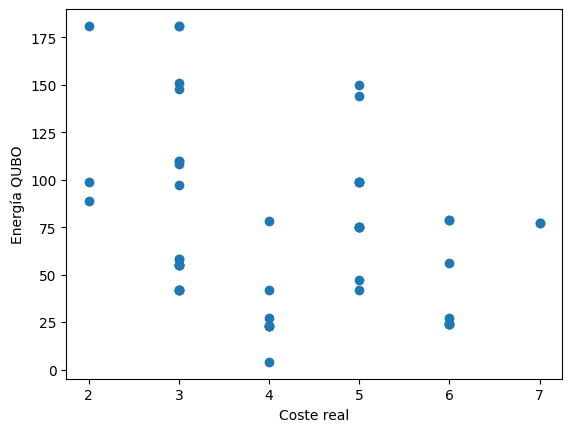

In [172]:
solutions_bits, energies, counts, extra = sampleset_to_arrays(sampleset, N)

K_esperado = None
circular = False

if varmap is None and (ciudades is not None) and (n_slots is not None):
    n_ciudades = len(ciudades)
    varmap = {i*n_slots + t: (i, t) for i in range(n_ciudades) for t in range(n_slots)}

if ciudades is None or n_slots is None or varmap is None:
    raise ValueError("Faltan metadatos: ciudades/n_slots/varmap.")
N = len(varmap)
if N != len(ciudades) * n_slots:
    raise ValueError(f"Inconsistencia: N={N} pero len(ciudades)*n_slots={len(ciudades)*n_slots}")

rows = []
for bits, e_qubo, c in zip(solutions_bits, energies, counts):
    ev = evaluar_bits(
        bits, lineal, cuadratica, desplazamiento,
        varmap, ciudades, n_slots, costes,
        indices_depositos=indices_depositos,
        circular=circular,
        K_esperado=K_esperado
    )

    factible = (ev["viol_pos"] == 0) and (ev["viol_una"] == 0) and (ev["viol_deposito"] == 0)

    rows.append({
        "energia_qubo": e_qubo,
        "conteo": c,
        "coste_real": ev["coste_real"],
        "factible": factible,
        "viol_pos": ev["viol_pos"],
        "viol_una": ev["viol_una"],
        "viol_deposito": ev["viol_deposito"],
    })

df = pd.DataFrame(rows)

plt.figure()
plt.scatter(df["coste_real"], df["energia_qubo"])
plt.xlabel("Coste real")
plt.ylabel("Energía QUBO")
plt.show()

In [173]:
fact_summary = {
    "n_total": int(len(df)),
    "n_factibles": int(df["factible"].sum()),
    "frac_factibles": float(df["factible"].mean()) if len(df) else 0.0,
    "best_energy_total": float(df["energia_qubo"].min()) if len(df) else None,
    "best_coste_real_total": float(df["coste_real"].min()) if len(df) else None,
}

if df["factible"].any():
    dff = df[df["factible"]]
    fact_summary["best_energy_factible"] = float(dff["energia_qubo"].min())
    fact_summary["best_coste_real_factible"] = float(dff["coste_real"].min())
else:
    fact_summary["best_energy_factible"] = None
    fact_summary["best_coste_real_factible"] = None

print(json.dumps(fact_summary, indent=2, ensure_ascii=False))

{
  "n_total": 51,
  "n_factibles": 1,
  "frac_factibles": 0.0196078431372549,
  "best_energy_total": 4.0,
  "best_coste_real_total": 2.0,
  "best_energy_factible": 4.0,
  "best_coste_real_factible": 4.0
}


In [174]:
mask_fact = df["factible"].to_numpy(dtype=bool)

solutions_f = solutions_bits[mask_fact]
counts_f = counts[mask_fact]

if len(solutions_f) == 0:
    print("No hay soluciones factibles; usando todas las soluciones para visualización.")
    solutions_f = solutions_bits
    counts_f = counts

print("Total muestras:", len(solutions_bits))
print("Factibles:", len(solutions_f))
print("Frac. factibles:", len(solutions_f) / max(1, len(solutions_bits)))

Total muestras: 51
Factibles: 1
Frac. factibles: 0.0196078431372549


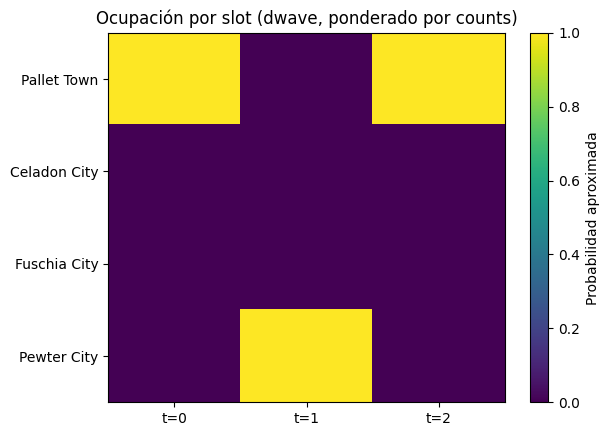

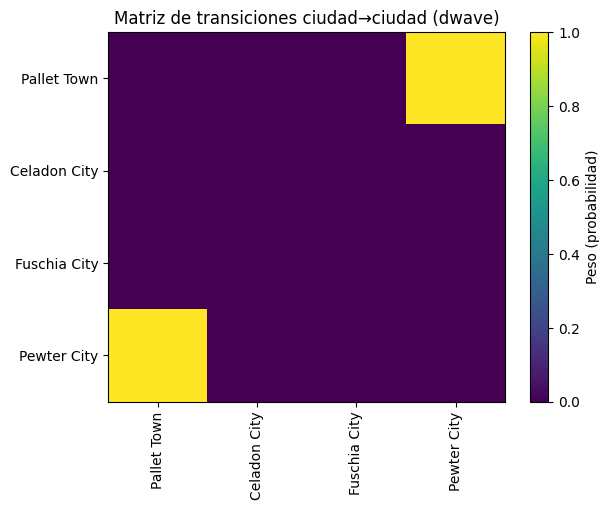

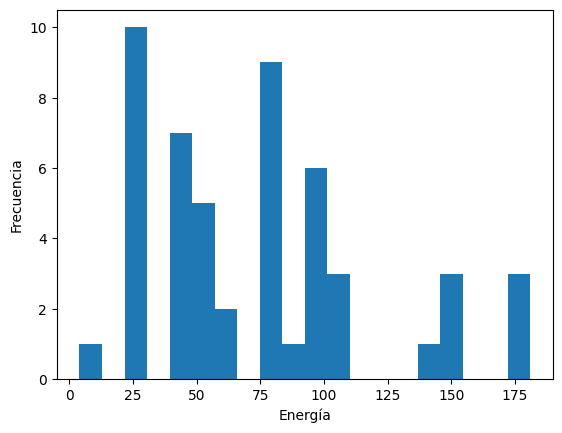

In [175]:
occ = heatmap_ocupacion(solutions_f, counts_f, varmap, len(ciudades), n_slots)

plt.figure()
plt.imshow(occ, aspect="auto")
plt.yticks(range(len(ciudades)), ciudades)
plt.xticks(range(n_slots), [f"t={t}" for t in range(n_slots)])
plt.colorbar(label="Probabilidad aproximada")
plt.title("Ocupación por slot (dwave, ponderado por counts)")
plt.show()

ht = heatmap_transiciones(solutions_f, counts_f, varmap, len(ciudades), n_slots, circular=False)

plt.figure()
plt.imshow(ht, aspect="auto")
plt.xticks(range(len(ciudades)), ciudades, rotation=90)
plt.yticks(range(len(ciudades)), ciudades)
plt.colorbar(label="Peso (probabilidad)")
plt.title("Matriz de transiciones ciudad→ciudad (dwave)")
plt.show()

plt.figure()
plt.hist(energies, bins=20)
plt.xlabel("Energía")
plt.ylabel("Frecuencia")
plt.show()

In [176]:
df_ordenado = df.sort_values(["energia_qubo", "coste_real"]).reset_index(drop=True)
df_ordenado.head(10)

,energia_qubo,conteo,coste_real,factible,viol_pos,viol_una,viol_deposito
0,4.0,1,4.0,True,0,0,0
1,23.0,5,4.0,False,1,0,0
2,23.0,1,4.0,False,1,0,0
3,23.0,1,4.0,False,1,0,0
4,23.0,1,4.0,False,1,0,0
5,24.0,1,6.0,False,1,0,0
6,24.0,1,6.0,False,1,0,0
7,24.0,1,6.0,False,1,0,0
8,24.0,1,6.0,False,1,0,0
9,27.0,1,4.0,False,1,0,0
